# Notebook 1 — Simulating Fluorescence Microscopy Images of Neurons

**BINFX410 · Chapter 10 · Connectomics**

---

## Learning Objectives

By the end of this notebook you will be able to:

1. Explain the basic components of a neuron visible in fluorescence microscopy
2. Generate synthetic neuron images with controlled morphology
3. Inspect and visualize ground-truth soma and synapse labels
4. Save image/label pairs for use in downstream machine-learning notebooks

---

## Background

**Connectomics** is the study of the complete map of neural connections (the *connectome*) within a nervous system or brain region. Mapping a connectome requires:

1. **Imaging** – acquiring high-resolution images of neurons (electron microscopy, fluorescence confocal, light-sheet, etc.)
2. **Segmentation** – identifying individual cells and processes in the images
3. **Synapse detection** – finding points where axon terminals contact target neurons
4. **Graph construction** – encoding connections as a directed graph
5. **Analysis** – applying graph theory and machine learning to understand circuit function

Real connectomic datasets (e.g., the *C. elegans* 302-neuron connectome or the Drosophila hemibrain with ~25,000 neurons) are complex and large. In this exercise we will **simulate** a small but realistic neuron population so that we know the ground truth and can benchmark our analysis pipeline.

### What our simulator produces

Each synthetic image contains:
- **Soma** – the round cell body of each neuron (bright Gaussian blobs)
- **Axons** – long branching processes that carry output signals away from the soma
- **Dendrites** – short branching processes that receive inputs
- **Synaptic terminals** – bright spots where an axon tip is close enough to a target soma to form a connection
- **Background fluorescence + shot noise** – realistic imaging artifacts

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import pickle

from utils.neuron_sim import generate_neuron_scene, make_ground_truth_masks

# Output directory for data shared across notebooks
DATA_DIR = Path('../data')
DATA_DIR.mkdir(exist_ok=True)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Generate a Single Scene

We will start by generating one synthetic image and examining its contents.

In [2]:
IMAGE_SIZE = (512, 512)
N_NEURONS  = 10
SEED       = 42

image, neurons, synapses = generate_neuron_scene(
    image_size=IMAGE_SIZE,
    n_neurons=N_NEURONS,
    seed=SEED,
    noise_level=0.04,
)

print(f'Image shape : {image.shape}')
print(f'Image dtype : {image.dtype}')
print(f'Pixel range : [{image.min():.4f}, {image.max():.4f}]')
print(f'Neurons     : {len(neurons)}')
print(f'Synapses    : {len(synapses)}')

Image shape : (512, 512)
Image dtype : float32
Pixel range : [0.0000, 1.0000]
Neurons     : 8
Synapses    : 7


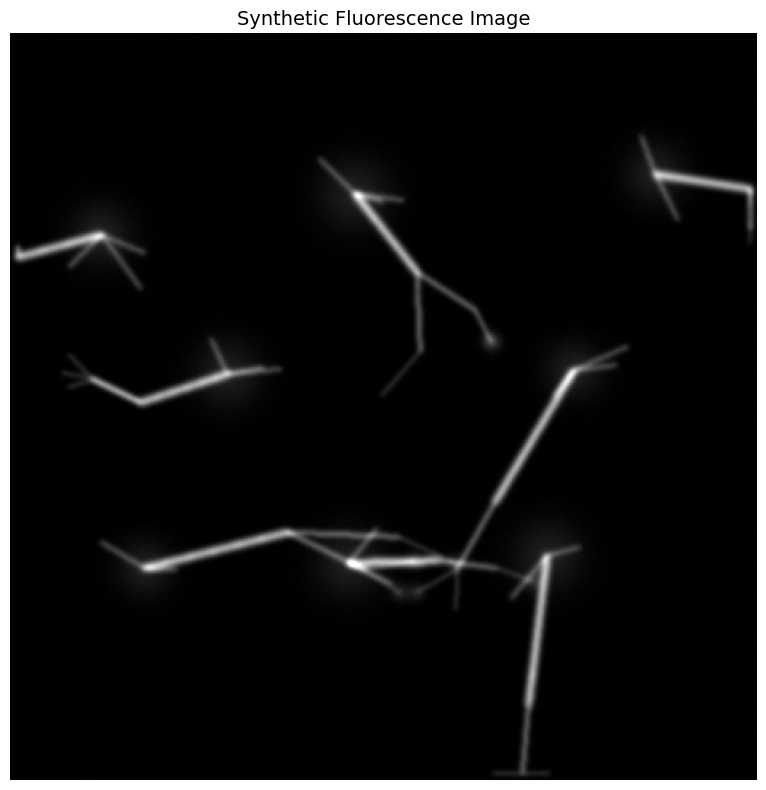

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(image, cmap='gray', vmin=0, vmax=0.8)
ax.set_title('Synthetic Fluorescence Image', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

## 2. Inspect the Ground-Truth Labels

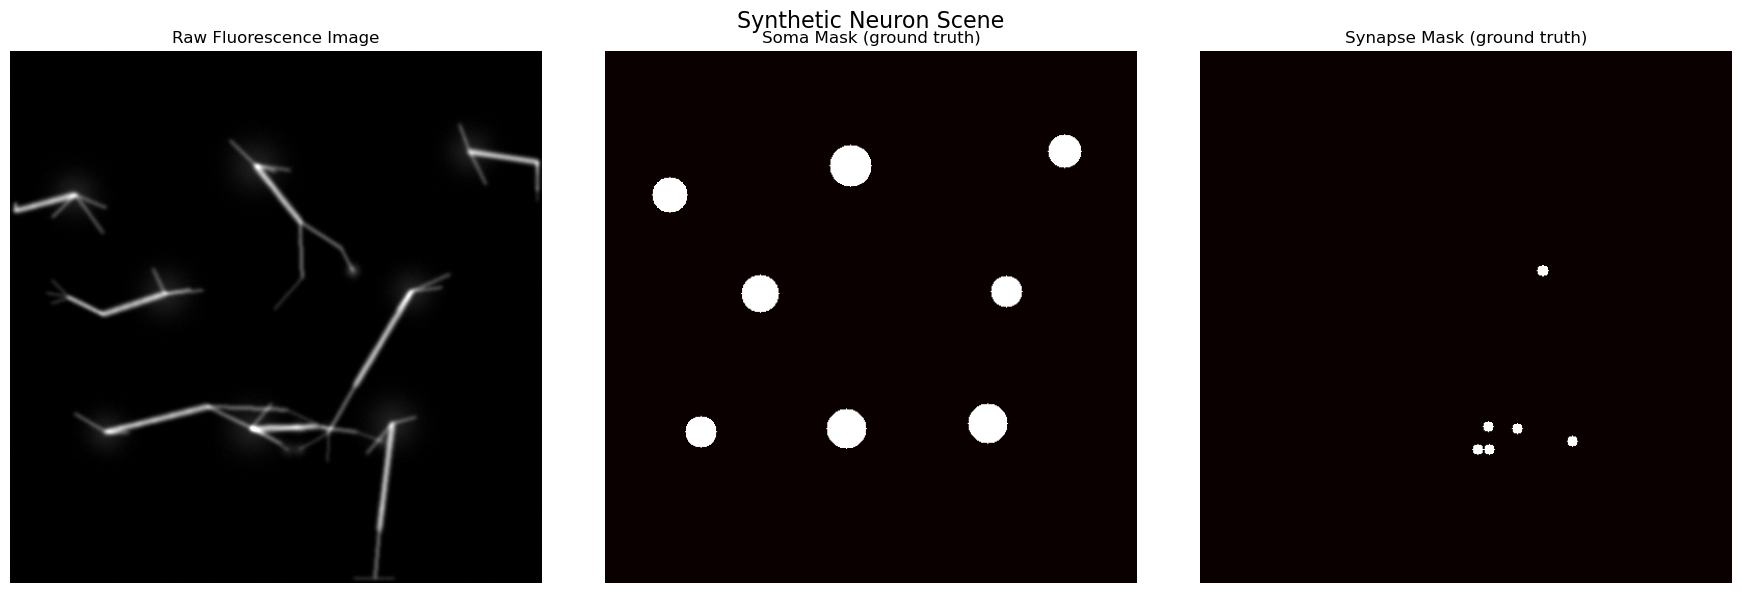

Soma pixels    : 7640
Synapse pixels : 497


In [4]:
soma_mask, synapse_mask = make_ground_truth_masks(IMAGE_SIZE, neurons, synapses)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image, cmap='gray', vmin=0, vmax=0.8)
axes[0].set_title('Raw Fluorescence Image')
axes[0].axis('off')

axes[1].imshow(soma_mask, cmap='hot')
axes[1].set_title('Soma Mask (ground truth)')
axes[1].axis('off')

axes[2].imshow(synapse_mask, cmap='hot')
axes[2].set_title('Synapse Mask (ground truth)')
axes[2].axis('off')

plt.suptitle('Synthetic Neuron Scene', fontsize=16)
plt.tight_layout()
plt.show()

print(f'Soma pixels    : {soma_mask.sum()}')
print(f'Synapse pixels : {synapse_mask.sum()}')

## 3. Overlay Ground-Truth Annotations on the Image

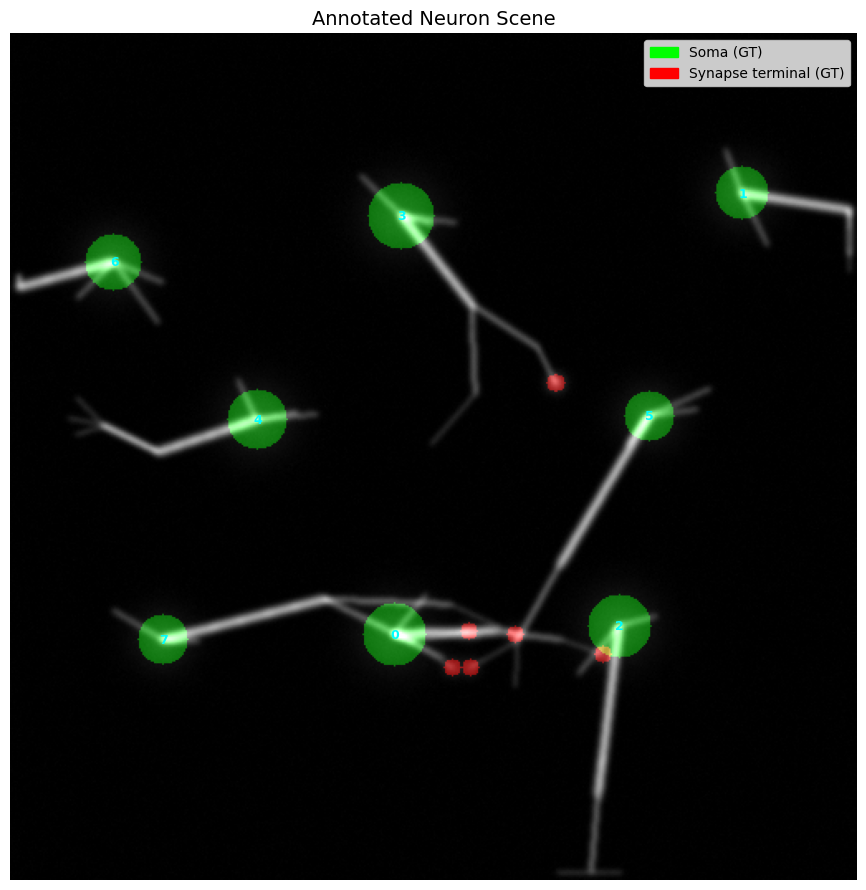

In [5]:
# Build an RGB overlay
rgb = np.stack([image, image, image], axis=-1)  # grayscale -> RGB
rgb = np.clip(rgb * 1.2, 0, 1)  # brighten slightly

# Tint soma regions green, synapse regions red
soma_overlay    = (soma_mask    > 0).astype(float)
synapse_overlay = (synapse_mask > 0).astype(float)

rgb[:, :, 0] = np.clip(rgb[:, :, 0] + 0.5 * synapse_overlay, 0, 1)  # red for synapses
rgb[:, :, 1] = np.clip(rgb[:, :, 1] + 0.4 * soma_overlay,    0, 1)  # green for soma

fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(rgb)

# Label each neuron
for n in neurons:
    r, c = n.soma_center
    ax.text(c, r, str(n.neuron_id), color='cyan', fontsize=9,
            ha='center', va='center', fontweight='bold')

green_patch = mpatches.Patch(color='lime',  label='Soma (GT)')
red_patch   = mpatches.Patch(color='red',   label='Synapse terminal (GT)')
ax.legend(handles=[green_patch, red_patch], loc='upper right', fontsize=10)
ax.set_title('Annotated Neuron Scene', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Inspect the Connectivity List (Ground Truth)

In [6]:
import pandas as pd

syn_records = [
    {
        'pre_id'  : s.pre_id,
        'post_id' : s.post_id,
        'loc_r'   : round(s.location[0], 1),
        'loc_c'   : round(s.location[1], 1),
        'strength': round(s.strength, 3),
    }
    for s in synapses
]

syn_df = pd.DataFrame(syn_records)
print('Ground-truth synaptic connections:')
print(syn_df.to_string(index=False))

Ground-truth synaptic connections:
 pre_id  post_id  loc_r  loc_c  strength
      0        2  375.6  358.0     0.732
      3        5  211.7  330.5     0.396
      3        5  211.6  329.4     0.390
      5        0  383.2  278.9     0.452
      7        0  383.6  267.3     0.530
      7        0  361.8  277.0     0.495
      7        2  363.3  305.2     0.373


## 5. Generate a Dataset of Multiple Scenes

For training the segmentation model in Notebook 2 we need multiple image/mask pairs.

In [ ]:
N_TRAIN = 40
N_VAL   = 10

def generate_dataset(n_samples, base_seed, n_neurons_range=(6, 14), size=(256, 256)):
    images, soma_masks, synapse_masks, metadata = [], [], [], []
    for i in range(n_samples):
        rng_local = np.random.default_rng(base_seed + i)
        n = int(rng_local.integers(*n_neurons_range))
        img, nrns, syns = generate_neuron_scene(
            image_size=size, n_neurons=n,
            seed=base_seed + i, noise_level=rng_local.uniform(0.02, 0.07)
        )
        sm, synm = make_ground_truth_masks(size, nrns, syns)
        images.append(img)
        soma_masks.append(sm)
        synapse_masks.append(synm)
        metadata.append({'neurons': nrns, 'synapses': syns})
        if (i + 1) % 10 == 0:
            print(f'  Generated {i + 1}/{n_samples}')
    return images, soma_masks, synapse_masks, metadata

print('Generating training set...')
train_imgs, train_soma, train_syn, train_meta = generate_dataset(N_TRAIN, base_seed=100)
print('Generating validation set...')
val_imgs, val_soma, val_syn, val_meta = generate_dataset(N_VAL, base_seed=9000)
print('Done.')

Generating training set...
  Generated 10/40
  Generated 20/40


In [ ]:
# Preview a few training samples
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
for col in range(6):
    axes[0, col].imshow(train_imgs[col], cmap='gray', vmin=0, vmax=0.8)
    axes[0, col].set_title(f'Sample {col}')
    axes[0, col].axis('off')
    axes[1, col].imshow(train_soma[col], cmap='hot')
    axes[1, col].set_title('Soma mask')
    axes[1, col].axis('off')
    axes[2, col].imshow(train_syn[col], cmap='hot')
    axes[2, col].set_title('Synapse mask')
    axes[2, col].axis('off')

axes[0, 0].set_ylabel('Image', fontsize=12)
plt.suptitle('Training Dataset Preview (6 / 40 samples)', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Save Dataset to Disk

In [ ]:
dataset = {
    'train': {
        'images'        : np.array(train_imgs),
        'soma_masks'    : np.array(train_soma),
        'synapse_masks' : np.array(train_syn),
        'metadata'      : train_meta,
    },
    'val': {
        'images'        : np.array(val_imgs),
        'soma_masks'    : np.array(val_soma),
        'synapse_masks' : np.array(val_syn),
        'metadata'      : val_meta,
    },
    # Full-resolution inference scene
    'inference': {
        'image'         : image,
        'soma_mask'     : soma_mask,
        'synapse_mask'  : synapse_mask,
        'neurons'       : neurons,
        'synapses'      : synapses,
        'image_size'    : IMAGE_SIZE,
    }
}

out_path = DATA_DIR / 'connectome_dataset.pkl'
with open(out_path, 'wb') as f:
    pickle.dump(dataset, f)

print(f'Dataset saved to: {out_path}')
print(f'  Train images shape : {dataset["train"]["images"].shape}')
print(f'  Val   images shape : {dataset["val"]["images"].shape}')

---

## Student Exercises

**Exercise 1.1** — Vary the `noise_level` parameter between 0.01 and 0.15. At what noise level does it become difficult to visually distinguish individual neurons? Regenerate the figures to support your answer.

**Exercise 1.2** — Modify the call to `generate_neuron_scene` to produce 20 neurons in a 512×512 image. What happens to the number of synapses? Why?

**Exercise 1.3** — Open `utils/neuron_sim.py` and read the `_draw_branching_axon` function. How does the `depth` parameter control the complexity of the axon arbor? Sketch (with pen and paper or matplotlib) what `depth=0`, `depth=1`, and `depth=3` would look like.

**Exercise 1.4** — The synapse detection in the simulator uses a simple distance threshold. What are the biological limitations of this approach? Name two real-world features of synapses that this model ignores.

**Exercise 1.5 (Challenge)** — Add a `intensity_variation` parameter to `generate_neuron_scene` that scales the brightness of each neuron independently (simulating different expression levels of the fluorescent reporter). Save new images to disk and compare with the originals.